
  **ROLANDO -> ROLE 1 — NLP & Intent**

  **Classification
  Banking Chatbot Final Project**
  **Model: Fine-tuned BERT on BANKING77 dataset**

WHAT THIS FILE DOES:
  1. Loads the BANKING77 dataset (77 banking intent classes)
  2. Tokenizes the text using BERT's tokenizer
  3. Fine-tunes a BERT model to classify user intents
  4. Evaluates with accuracy, F1, confusion matrix, and
     a full per-intent classification report
  5. Saves the model so other teammates can load it
  6. Exposes a simple predict_intent() function for the pipeline

HOW TO RUN:
  - pip install transformers datasets torch scikit-learn seaborn matplotlib
  - python intent_classification.py

In [2]:
# 1. IMPORTS

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,)

In [3]:
# 2. CONFIGURATION

MODEL_NAME = "bert-base-uncased"  # pre-trained BERT we start from
OUTPUT_DIR = "./intent_model"     # where the finetuned model is saved
EPOCHS = 3                        # how many times to train over the data
BATCH_SIZE = 16                   # samples per training step
MAX_LENGTH = 64                   # max token length per sentence
LEARNING_RATE = 2e-5              # how fast the model learns

# A consistent colour palette
COLOURS = {
    'primary'  : '#264653',
    'secondary': '#E76F51',
    'tertiary' : '#2A9D8F',
    'accent'   : '#E63946',
}

In [4]:
# 3. LOAD DATASET

print("\n[1/5] Loading BANKING77 dataset...")
dataset = load_dataset("banking77")

train_data = dataset["train"]
test_data  = dataset["test"]

# Number of unique intents (77 in BANKING77 dataset)
NUM_LABELS = len(train_data.features["label"].names)
LABEL_NAMES = train_data.features["label"].names  # list of intent strings

print(f"    Training samples : {len(train_data)}")
print(f"    Test samples     : {len(test_data)}")
print(f"    Number of intents: {NUM_LABELS}")
print(f"    Example intents  : {LABEL_NAMES[:5]} ...")

# The dataset has 'train' and 'test' splits, each with:
#   - 'text'  : the user's message  e.g. "What's my balance?"
#   - 'label' : an integer 0-76     e.g. 3


[1/5] Loading BANKING77 dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/298k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

    Training samples : 10003
    Test samples     : 3080
    Number of intents: 77
    Example intents  : ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up'] ...


In [5]:
# 4. TOKENIZER

print("\n[2/5] Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    """Convert raw text into token IDs that BERT understands."""
    return tokenizer(
        batch["text"],
        padding="max_length",   # pad short sentences to MAX_LENGTH
        truncation=True,        # cut long sentences at MAX_LENGTH
        max_length=MAX_LENGTH,
    )

# Apply tokenization to the whole dataset
train_data = train_data.map(tokenize, batched=True)
test_data  = test_data.map(tokenize, batched=True)

# Tell the dataset which columns PyTorch needs
train_data.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_data.set_format("torch",  columns=["input_ids", "attention_mask", "label"])



[2/5] Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

In [6]:
# 5. LOAD BERT MODEL

print("\n[3/5] Loading BERT model for classification...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,   # 77 output neurons, one per intent
)


[3/5] Loading BERT model for classification...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
# 6. METRICS FUNCTION

def compute_metrics(eval_pred):
    """Called automatically by Trainer after each evaluation step."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)   # pick the highest-score intent

    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average="weighted")

    return {"accuracy": round(acc, 4), "f1": round(f1, 4)}

In [8]:
training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    num_train_epochs = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    learning_rate = LEARNING_RATE,
    eval_strategy = "epoch",    # evaluate after every epoch
    save_strategy = "epoch",    # save checkpoint after every epoch
    load_best_model_at_end = True,    # keep the best checkpoint
    metric_for_best_model = "f1",
    logging_dir = "./logs",
    logging_steps = 50,
    report_to = "none"     # disable wandb and/or other trackers
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [9]:
# 8. TRAINER: HuggingFace handles the training loop for us

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_data,
    eval_dataset = test_data,
    compute_metrics = compute_metrics,
)

In [10]:
# 9. TRAIN THE MODEL

print("\n[4/5] Fine-tuning BERT on BANKING77 ...")
print("   (This might take a while on CPU (~20 min or much more), thats why we use GPU)\n")
trainer.train()


[4/5] Fine-tuning BERT on BANKING77 ...
   (This might take a while on CPU (~20 min or much more), thats why we use GPU)



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.284198,2.036515,0.726300,0.700900
2,1.192237,1.115438,0.852300,0.837400
3,0.875659,0.893802,0.880200,0.874800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1878, training_loss=1.9075878517061504, metrics={'train_runtime': 449.1069, 'train_samples_per_second': 66.819, 'train_steps_per_second': 4.182, 'total_flos': 987627072862080.0, 'train_loss': 1.9075878517061504, 'epoch': 3.0})


[5/6] Evaluating on test set...



  Accuracy : 0.8802
  F1 Score : 0.8748

 Per-Intent Classification Report
  (Will be used later for benchmarking)

                                                  precision    recall  f1-score   support

                                activate_my_card       0.97      0.95      0.96        40
                                       age_limit       1.00      1.00      1.00        40
                         apple_pay_or_google_pay       0.93      1.00      0.96        40
                                     atm_support       1.00      0.97      0.99        40
                                automatic_top_up       1.00      0.95      0.97        40
         balance_not_updated_after_bank_transfer       0.61      0.78      0.68        40
balance_not_updated_after_cheque_or_cash_deposit       0.95      0.95      0.95        40
                         beneficiary_not_allowed       0.95      0.88      0.91        40
                                 cancel_transfer       0.97      0.90   

  Train accuracy : 0.9294
  Test  accuracy : 0.8802
  Gap : +0.0492  (good —> model is generalising)

 Generating Confusion Matrix (top 10 most confused intents)...


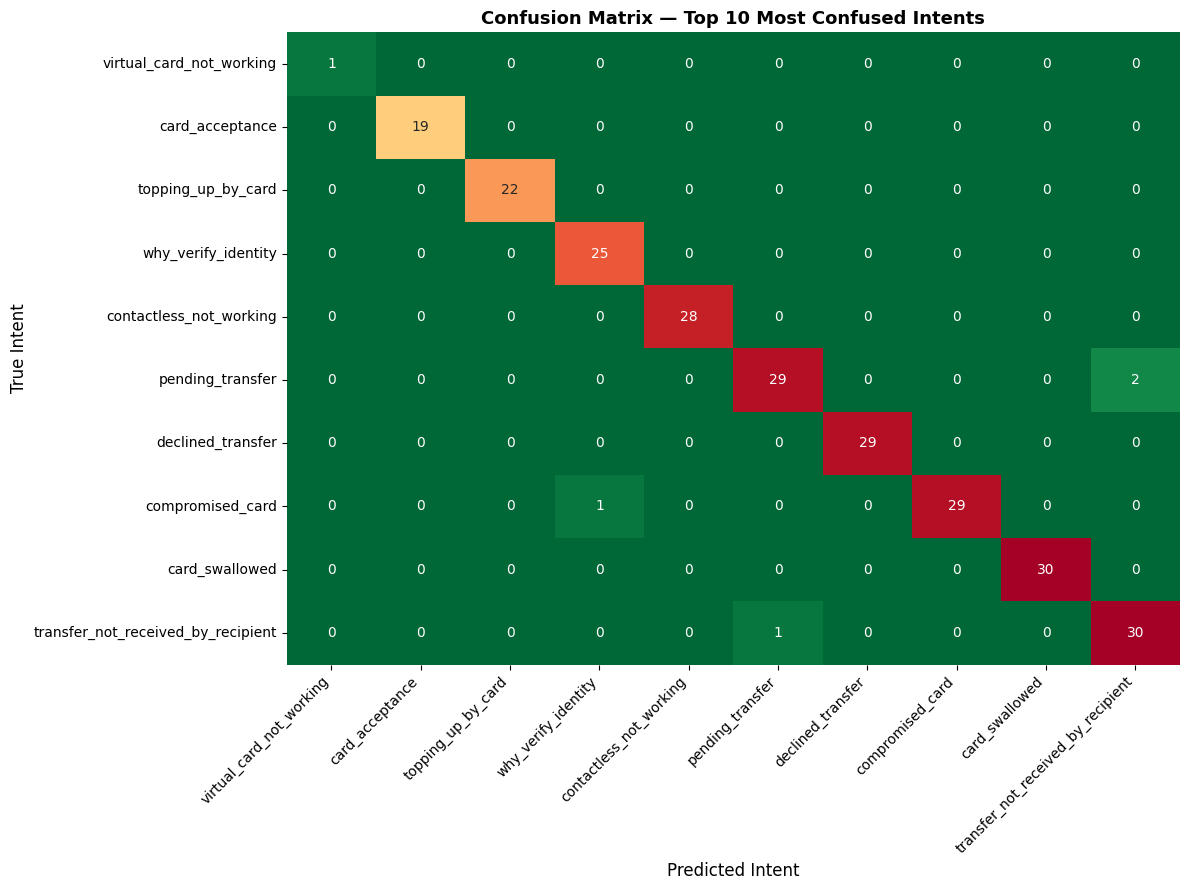

  Saved: confusion_matrix.png


In [11]:
# 10. EVALUATION

print("\n[5/6] Evaluating on test set...")

# Basic metrics
results = trainer.evaluate()
print(f"\n  Accuracy : {results['eval_accuracy']}")
print(f"  F1 Score : {results['eval_f1']}")

# Full per-intent classification report
predictions_output = trainer.predict(test_data)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

print("\n Per-Intent Classification Report")
print("  (Will be used later for benchmarking)\n")
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

# Generalisation gap
train_results = trainer.evaluate(train_data)
gap = train_results['eval_accuracy'] - results['eval_accuracy']
print(f"  Train accuracy : {train_results['eval_accuracy']:.4f}")
print(f"  Test  accuracy : {results['eval_accuracy']:.4f}")
print(f"  Gap : {gap:+.4f}  {'(good —> model is generalising)' if gap < 0.05 else '(watch out! —> possible overfitting)'}")

# Confusion matrix heatmap for TOP 10 most confused intents (All 77 are not required)
print("\n Generating Confusion Matrix (top 10 most confused intents)...")

cm = confusion_matrix(y_true, y_pred)
errors_per_intent = cm.sum(axis=1) - np.diag(cm)
top10_idx    = np.argsort(errors_per_intent)[-10:][::-1]
cm_top10     = cm[np.ix_(top10_idx, top10_idx)]
labels_top10 = [LABEL_NAMES[i] for i in top10_idx]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_top10, annot=True, fmt='d', cmap='RdYlGn_r',
    xticklabels=labels_top10, yticklabels=labels_top10,
    cbar=False, ax=ax,
)

ax.set_xlabel('Predicted Intent', fontsize=12)
ax.set_ylabel('True Intent', fontsize=12)
ax.set_title('Confusion Matrix — Top 10 Most Confused Intents', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("  Saved: confusion_matrix.png")


In [12]:
# 11. SAVE MODEL + TOKENIZER FOR ROLE 4 & 5

print(f"\n[6/6] Saving model to {OUTPUT_DIR}/ ...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"  Model saved — teammates can load it with:")
print(f"  BertForSequenceClassification.from_pretrained('{OUTPUT_DIR}')")


[6/6] Saving model to ./intent_model/ ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Model saved — teammates can load it with:
  BertForSequenceClassification.from_pretrained('./intent_model')


In [16]:
# 12. PREDICT FUNCTION
#     **What the chatbot pipeline will call

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predict_intent(user_message: str) -> dict:
    """
    Given a user's message, return the predicted intent and confidence score.

    Usage (from any other teammate's file):
        from intent_classification import predict_intent
        result = predict_intent("What is my account balance?")
        print(result)
        # → {'intent': 'balance_inquiry', 'confidence': 0.97, 'label_id': 5}

    Args:
        user_message (str): Raw text from the user

    Returns:
        dict with keys:
            - 'intent'     : human-readable intent name  (str)
            - 'confidence' : probability 0.0 → 1.0       (float)
            - 'label_id'   : integer class index          (int)
    """
    # Make sure model is in evaluation mode (not training mode)
    model.eval()

    # Tokenize the single input message
    inputs = tokenizer(
        user_message,
        return_tensors="pt",      # PyTorch tensors
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    # Run through the model (no gradient calculation needed for inference)

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    # Convert raw scores (logits) to probabilities
    probs = torch.softmax(outputs.logits, dim=1)
    label_id = torch.argmax(probs).item()
    confidence = probs[0][label_id].item()

    return {
        "intent" : LABEL_NAMES[label_id],
        "confidence": round(confidence, 4),
        "label_id" : label_id,
    }

In [17]:
# 13. QUICK DEMO (WILL run only when this file is directly executed)
if __name__ == "__main__":
    test_sentences = [
        "What is my current balance?",
        "I want to transfer money to my friend",
        "How do I apply for a loan?",
        "My card was stolen, please block it",
        "What are your interest rates?",
    ]

    print("\n >>>>>>>>>>>> Quick Demo <<<<<<<<<<<")
    for sentence in test_sentences:
        result = predict_intent(sentence)
        print(f"  Input : {sentence}")
        print(f"  Intent : {result['intent']}")
        print(f"  Confidence : {result['confidence']:.0%}")
        print()



 >>>>>>>>>>>> Quick Demo <<<<<<<<<<<
  Input : What is my current balance?
  Intent : balance_not_updated_after_bank_transfer
  Confidence : 40%

  Input : I want to transfer money to my friend
  Intent : transfer_into_account
  Confidence : 19%

  Input : How do I apply for a loan?
  Intent : receiving_money
  Confidence : 11%

  Input : My card was stolen, please block it
  Intent : lost_or_stolen_card
  Confidence : 15%

  Input : What are your interest rates?
  Intent : exchange_rate
  Confidence : 54%



**MY QUICK DEMO**

**>>>>>>>>>>>> Quick Demo <<<<<<<<<<<**

  Input : What is my current balance?

  Intent : balance_not_updated_after_bank_transfer

  Confidence : 40%
  ________________________________________________

  Input : I want to transfer money to my friend

  Intent : transfer_into_account

  Confidence : 19%
  ________________________________________________

  Input : How do I apply for a loan?

  Intent : receiving_money

  Confidence : 11%
  ________________________________________________

  Input : My card was stolen, please block it

  Intent : lost_or_stolen_card

  Confidence : 15%
  ________________________________________________

  Input : What are your interest rates?

  Intent : exchange_rate
  
  Confidence : 54%

**PERSONAL OBSERVATIONS**

This is a good baseline model, but it is not yet a **RELIABLE** banking assistant.

The 0.8802 accuracy is solid and F1 0.8748 is decent across classes, but on the quick demo I could notice that the confidece percentage is overall low and in some cases even wrong.

The current stage is learning well and generalizing properly, BUT its getting really confused at multiple intents (balance, transfer, interest rates).

I'll try to fix & experiment later on:
- The inference confidence
- Hyperparameter tuning
- Try better BERT variant (roberta-base -> better for classification)
- Try to solve confusion hotspots (for this demo stage)
- PERHAPS for Role 5 add intent grouping layer or some other way to avoid confusion and error :/

e.g.
Map into categories (payments, cards, transfers, identity, top-ups, account info)

Rolando Vazquez



